# Clustermaps in Seaborn

A **Clustermap** (`sns.clustermap`) performs **hierarchical agglomerative clustering** on both rows and columns of a 2D matrix.
It reorders rows and columns based on similarity and displays **dendrograms** along the borders.


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

flights_path = os.path.join("datasets", "flights.csv")
if os.path.exists(flights_path):
    flights = pd.read_csv(flights_path)
else:
    flights = sns.load_dataset("flights")

flight_matrix = flights.pivot(index="month", columns="year", values="passengers")
flight_matrix.head()


year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Apr,129,135,163,181,235,227,269,313,348,348,396,461
Aug,148,170,199,242,272,293,347,405,467,505,559,606
Dec,118,140,166,194,201,229,278,306,336,337,405,432
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Jan,112,115,145,171,196,204,242,284,315,340,360,417


## 1. Clustermap with Standard Scale
`standard_scale=1` standardizes values across columns between 0 and 1, highlighting seasonal flight patterns regardless of annual growth.


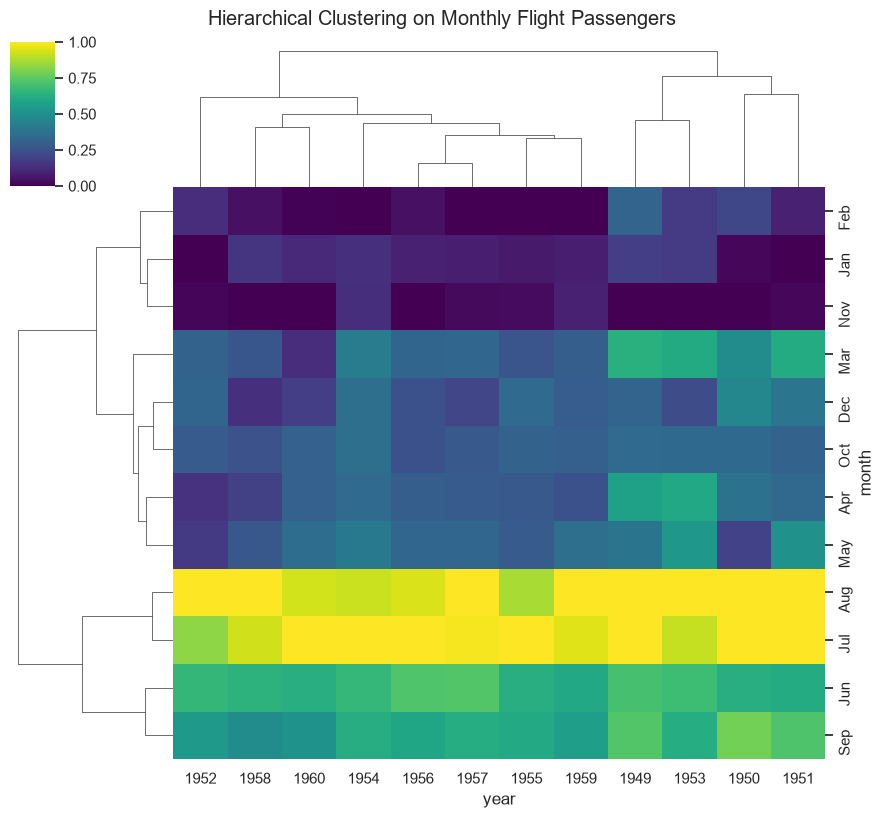

In [2]:
g = sns.clustermap(
    flight_matrix,
    cmap="viridis",
    standard_scale=1,
    metric="euclidean",
    method="average",
    figsize=(9, 8)
)
g.fig.suptitle("Hierarchical Clustering on Monthly Flight Passengers", y=1.02)
plt.show()


## 2. Row-Only Clustering (Preserve Chronological Years)
Set `col_cluster=False` to cluster months by seasonal similarity while keeping calendar years in order.


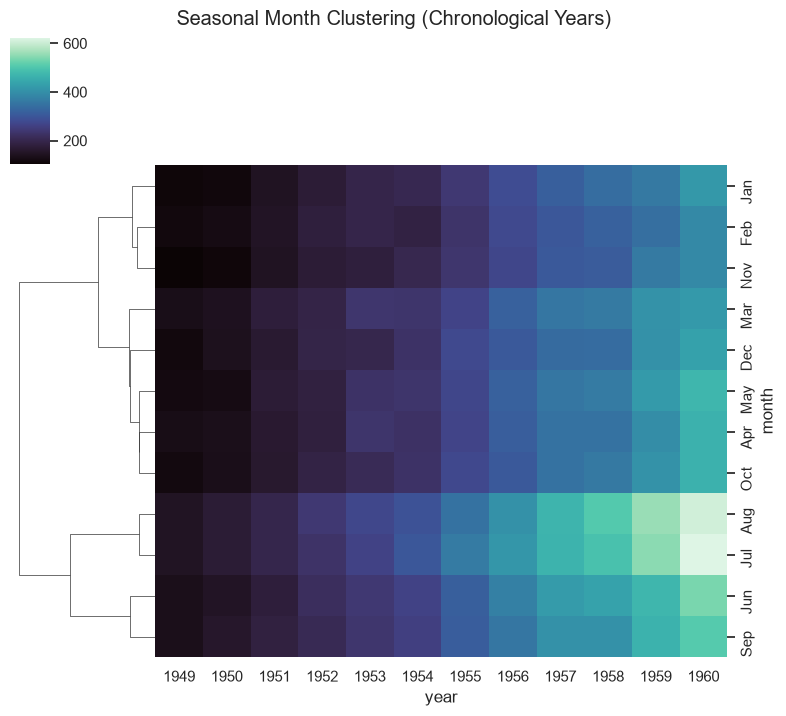

In [3]:
g2 = sns.clustermap(
    flight_matrix,
    cmap="mako",
    col_cluster=False,
    figsize=(8, 7)
)
g2.fig.suptitle("Seasonal Month Clustering (Chronological Years)", y=1.02)
plt.show()
